# EveryQuery vs EIC: Multi-Duration Results

Single analysis notebook for the updated preprint. Loads EQ multi-duration eval,
EIC baseline, and prevalence data, then runs verification, statistical comparisons,
loss characterization, and generates all figures inline.

## Setup and Data Loading

In [75]:
from pathlib import Path
FIG_DIR = Path("/Users/payalchandak/Desktop/EveryQuery/SD4H/figures")

In [76]:
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import polars as pl
from scipy import stats as sp_stats

matplotlib.rcParams.update({
    "font.size": 11,
    "font.family": "sans-serif",
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

%matplotlib inline

REPO = Path(".").resolve().parent
DATA = REPO / "data"

EQ_MODEL_DIR = DATA / "outputs" / "2026-04-02" / "23-43-54"
EQ_PARQUET = EQ_MODEL_DIR / "eval" / "best" / "eval_aucs_held_out_20260410_192213.parquet"
EIC_PARQUET = DATA / "baselines" / "eic" / "temporal_auc_results_10000_ID__8db2be6fadf8.parquet"
PREVALENCE_CSV = DATA / "held_out_prevalence_7573f855c4b050a9d79d57fefd8a139c.csv"

DURATIONS = [30, 90, 180, 365, 730]
TRAINED_DURATIONS = {30, 180}
OOD_DURATIONS = {90, 365, 730}
INTERP_OOD = {90}
EXTRAP_OOD = {365, 730}

# Load EQ
eq_raw = pl.read_parquet(EQ_PARQUET).with_columns(
    pl.when(pl.col("duration_days") == 731).then(730)
    .otherwise(pl.col("duration_days")).alias("duration_days")
)

# Load EIC (wide -> long)
eic_wide = pl.read_parquet(EIC_PARQUET).with_columns(
    (pl.col("duration").dt.total_microseconds() / (1e6 * 86400))
    .cast(pl.Int64).alias("duration_days")
)
auc_cols = [c for c in eic_wide.columns if c.startswith("AUC/")]
eic_raw = eic_wide.unpivot(
    on=auc_cols, index=["duration_days"],
    variable_name="code_slug_raw", value_name="eic_auc",
).with_columns(
    pl.col("code_slug_raw").str.strip_prefix("AUC/").alias("code_slug")
).drop("code_slug_raw")

# Load prevalence
prev_raw = pl.read_csv(PREVALENCE_CSV).with_columns(
    pl.when(pl.col("duration_days") == 731).then(730)
    .otherwise(pl.col("duration_days")).alias("duration_days")
)

# Inner join EQ + EIC, filter nulls, compute delta
joined_raw = eq_raw.join(eic_raw, on=["code_slug", "duration_days"], how="inner")
joined = (
    joined_raw
    .filter(pl.col("occurs_auc").is_not_null() & pl.col("eic_auc").is_not_null())
    .with_columns((pl.col("occurs_auc") - pl.col("eic_auc")).alias("delta_auc"))
)
df = joined.join(prev_raw, on=["code", "duration_days"], how="inner")

print(f"EQ: {eq_raw.shape[0]} rows, EIC: {eic_raw.shape[0]} rows")
print(f"Joined: {len(joined)} paired evaluations, {joined['code_slug'].n_unique()} codes x {len(DURATIONS)} durations")
print(f"With prevalence: {len(df)} rows")

EQ: 205 rows, EIC: 200 rows
Joined: 199 paired evaluations, 40 codes x 5 durations
With prevalence: 199 rows


## Data Verification

In [77]:
# Null audit
nulls = {c: joined[c].null_count() for c in joined.columns if joined[c].null_count() > 0}
if nulls:
    print(f"Columns with nulls: {nulls}")
else:
    print("No nulls")

# Bucket distribution
id_n = joined.filter(pl.col("bucket") == "id").shape[0]
ood_n = joined.filter(pl.col("bucket") == "ood").shape[0]
print(f"Buckets: {id_n} ID, {ood_n} OOD")

# Summary stats
summary_cols = ["occurs_auc", "eic_auc", "delta_auc"]
print("\nOverall:")
for col in summary_cols:
    arr = joined[col].to_numpy()
    print(f"  {col}: mean={arr.mean():.4f}, median={np.median(arr):.4f}, std={arr.std():.4f}")

Columns with nulls: {'censor_auc': 199}
Buckets: 105 ID, 94 OOD

Overall:
  occurs_auc: mean=0.8360, median=0.8842, std=0.1441
  eic_auc: mean=0.6698, median=0.6616, std=0.1151
  delta_auc: mean=0.1663, median=0.1660, std=0.1672


## Main Text Results

### Analysis 1: EQ vs EIC Aggregate

In [78]:
def bootstrap_ci(deltas: np.ndarray, n_boot: int = 10000, alpha: float = 0.05, seed: int = 42):
    rng = np.random.default_rng(seed)
    means = np.array([
        deltas[rng.integers(0, len(deltas), size=len(deltas))].mean()
        for _ in range(n_boot)
    ])
    lo = np.percentile(means, 100 * alpha / 2)
    hi = np.percentile(means, 100 * (1 - alpha / 2))
    return lo, hi


def compute_metrics(sub: pl.DataFrame):
    deltas = sub["delta_auc"].to_numpy()
    n = len(deltas)
    wins = int((deltas > 0).sum())
    mean_d = float(deltas.mean())
    median_d = float(np.median(deltas))
    lo, hi = bootstrap_ci(deltas)
    if n >= 10:
        _, p = sp_stats.wilcoxon(
            sub["occurs_auc"].to_numpy(),
            sub["eic_auc"].to_numpy(),
            alternative="two-sided",
        )
    else:
        p = float("nan")
    return {
        "N_pairs": n,
        "EQ_wins": wins,
        "Win%": round(100 * wins / n, 1),
        "Mean_dAUC": round(mean_d, 4),
        "Median_dAUC": round(median_d, 4),
        "95%_CI": f"[{lo:.4f}, {hi:.4f}]",
        "Wilcoxon_p": p,
    }

# Part A: Overall metrics
m = compute_metrics(joined)
print("Overall EQ vs EIC comparison")
print(f"  N paired tasks x durations : {m['N_pairs']}")
print(f"  EQ wins                    : {m['EQ_wins']} / {m['N_pairs']}  ({m['Win%']}%)")
print(f"  Mean delta AUC (EQ - EIC)  : {m['Mean_dAUC']}")
print(f"  Median delta AUC           : {m['Median_dAUC']}")
print(f"  95% bootstrap CI (mean)    : {m['95%_CI']}")
print(f"  Wilcoxon signed-rank p     : {m['Wilcoxon_p']:.4e}")

# Part B: Per-duration breakdown
rows_b = []
for dur in DURATIONS:
    sub = joined.filter(pl.col("duration_days") == dur)
    if len(sub) == 0:
        continue
    met = compute_metrics(sub)
    rows_b.append({
        "Duration": dur,
        "Trained": "ID" if dur in TRAINED_DURATIONS else "OOD",
        **met,
    })

pl.DataFrame(rows_b)

Overall EQ vs EIC comparison
  N paired tasks x durations : 199
  EQ wins                    : 170 / 199  (85.4%)
  Mean delta AUC (EQ - EIC)  : 0.1663
  Median delta AUC           : 0.166
  95% bootstrap CI (mean)    : [0.1432, 0.1890]
  Wilcoxon signed-rank p     : 3.8229e-24


Duration,Trained,N_pairs,EQ_wins,Win%,Mean_dAUC,Median_dAUC,95%_CI,Wilcoxon_p
i64,str,i64,i64,f64,f64,f64,str,f64
30,"""ID""",39,33,84.6,0.1657,0.1697,"""[0.1133, 0.2167]""",8.5446e-7
90,"""OOD""",40,34,85.0,0.1581,0.1702,"""[0.1012, 0.2125]""",0.000002
180,"""ID""",40,35,87.5,0.1791,0.1641,"""[0.1292, 0.2282]""",5.0639e-8
365,"""OOD""",40,34,85.0,0.1564,0.1565,"""[0.1013, 0.2082]""",0.000006
730,"""OOD""",40,34,85.0,0.1719,0.1737,"""[0.1245, 0.2194]""",6.4607e-8


### Analysis 2: Duration OOD Formal Tests

In [79]:
# Split by trained (ID) vs untrained (OOD) durations
id_mask = joined["duration_days"].is_in(list(TRAINED_DURATIONS))
ood_mask = joined["duration_days"].is_in(list(OOD_DURATIONS))

# ---- Test 1: ΔAUC distributions (trained vs untrained) ----
delta_id = joined.filter(id_mask)["delta_auc"].to_numpy()
delta_ood = joined.filter(ood_mask)["delta_auc"].to_numpy()

stat_delta, p_delta = sp_stats.mannwhitneyu(delta_id, delta_ood, alternative="two-sided")

print("Test 1: ΔAUC (EQ - EIC) by duration type")
print(f"  Trained (30d, 180d):     N={len(delta_id):>3}, "
      f"mean={delta_id.mean():.4f}, median={np.median(delta_id):.4f}")
print(f"  Untrained (90-730d):     N={len(delta_ood):>3}, "
      f"mean={delta_ood.mean():.4f}, median={np.median(delta_ood):.4f}")
print(f"  Mann-Whitney U={stat_delta:.1f}, p={p_delta:.4f}")

# ---- Test 2: EQ AUC distributions (trained vs untrained) ----
auc_id = joined.filter(id_mask)["occurs_auc"].to_numpy()
auc_ood = joined.filter(ood_mask)["occurs_auc"].to_numpy()

stat_auc, p_auc = sp_stats.mannwhitneyu(auc_id, auc_ood, alternative="two-sided")

print("\nTest 2: EQ AUC (absolute) by duration type")
print(f"  Trained (30d, 180d):     N={len(auc_id):>3}, "
      f"mean={auc_id.mean():.4f}, median={np.median(auc_id):.4f}")
print(f"  Untrained (90-730d):     N={len(auc_ood):>3}, "
      f"mean={auc_ood.mean():.4f}, median={np.median(auc_ood):.4f}")
print(f"  Mann-Whitney U={stat_auc:.1f}, p={p_auc:.4f}")

# ---- Test 3: Win rate Fisher's exact test ----
wins_id = int((delta_id > 0).sum())
losses_id = len(delta_id) - wins_id
wins_ood = int((delta_ood > 0).sum())
losses_ood = len(delta_ood) - wins_ood

table = np.array([[wins_id, losses_id],
                   [wins_ood, losses_ood]])
odds_ratio, p_fisher = sp_stats.fisher_exact(table, alternative="two-sided")

print("\nTest 3: Win rate (ΔAUC > 0) by duration type")
print(f"                   Wins  Losses  Win rate")
print(f"  Trained:         {wins_id:>4}  {losses_id:>6}    {wins_id / len(delta_id):.1%}")
print(f"  Untrained:       {wins_ood:>4}  {losses_ood:>6}    {wins_ood / len(delta_ood):.1%}")
print(f"  Fisher's exact: OR={odds_ratio:.3f}, p={p_fisher:.4f}")

# ---- Test 4: Kruskal-Wallis (ID vs Interpolation vs Extrapolation) ----
delta_interp = joined.filter(
    pl.col("duration_days").is_in(list(INTERP_OOD))
)["delta_auc"].to_numpy()
delta_extrap = joined.filter(
    pl.col("duration_days").is_in(list(EXTRAP_OOD))
)["delta_auc"].to_numpy()

stat_kw, p_kw = sp_stats.kruskal(delta_id, delta_interp, delta_extrap)

print("\nTest 4: Kruskal-Wallis (ID vs Interpolation vs Extrapolation)")
print(f"  ID (30d, 180d):          N={len(delta_id):>3}, mean={delta_id.mean():.4f}")
print(f"  Interp OOD (90d):        N={len(delta_interp):>3}, mean={delta_interp.mean():.4f}")
print(f"  Extrap OOD (365d, 730d): N={len(delta_extrap):>3}, mean={delta_extrap.mean():.4f}")
print(f"  Kruskal-Wallis H={stat_kw:.3f}, p={p_kw:.4f}")

Test 1: ΔAUC (EQ - EIC) by duration type
  Trained (30d, 180d):     N= 79, mean=0.1725, median=0.1697
  Untrained (90-730d):     N=120, mean=0.1621, median=0.1658
  Mann-Whitney U=4842.0, p=0.7985

Test 2: EQ AUC (absolute) by duration type
  Trained (30d, 180d):     N= 79, mean=0.8520, median=0.8957
  Untrained (90-730d):     N=120, mean=0.8255, median=0.8725
  Mann-Whitney U=5244.0, p=0.2053

Test 3: Win rate (ΔAUC > 0) by duration type
                   Wins  Losses  Win rate
  Trained:           68      11    86.1%
  Untrained:        102      18    85.0%
  Fisher's exact: OR=1.091, p=1.0000

Test 4: Kruskal-Wallis (ID vs Interpolation vs Extrapolation)
  ID (30d, 180d):          N= 79, mean=0.1725
  Interp OOD (90d):        N= 40, mean=0.1581
  Extrap OOD (365d, 730d): N= 80, mean=0.1642
  Kruskal-Wallis H=0.077, p=0.9624


### Loss Summary and Code-Bucket Breakdown

In [80]:
# Loss concentration summary
n_total = len(joined)
n_losses = joined.filter(pl.col("delta_auc") < 0).shape[0]
print(f"Total (code, duration) evaluations: {n_total}")
print(f"Losses (EIC > EQ): {n_losses} ({n_losses / n_total:.1%})")

# Per-code win counts across all 5 durations
all_slugs = sorted(joined["code_slug"].unique().to_list())
win_all = 0
lose_all_codes = []
for slug in all_slugs:
    sub = joined.filter(pl.col("code_slug") == slug)
    wins = (sub["delta_auc"] > 0).sum()
    losses = (sub["delta_auc"] < 0).sum()
    if losses == 0:
        win_all += 1
    if wins == 0 and losses == len(sub):
        lose_all_codes.append(slug)

print(f"\nCodes winning at all evaluated durations: {win_all}/{len(all_slugs)}")
print(f"Codes losing at all evaluated durations: {len(lose_all_codes)}/{len(all_slugs)}")
if lose_all_codes:
    for c in lose_all_codes:
        print(f"  - {c}")

# Aggregate code-OOD vs code-ID win rate comparison
id_codes = joined.filter(pl.col("bucket") == "id")
ood_codes = joined.filter(pl.col("bucket") == "ood")

wins_id_code = int((id_codes["delta_auc"] > 0).sum())
losses_id_code = len(id_codes) - wins_id_code
wins_ood_code = int((ood_codes["delta_auc"] > 0).sum())
losses_ood_code = len(ood_codes) - wins_ood_code

table_code = np.array([[wins_id_code, losses_id_code],
                        [wins_ood_code, losses_ood_code]])
or_code, p_code = sp_stats.fisher_exact(table_code, alternative="two-sided")

print(f"\nCode-OOD generalization (aggregate across all durations):")
print(f"  ID codes:  {wins_id_code}/{len(id_codes)} wins ({wins_id_code / len(id_codes):.1%})")
print(f"  OOD codes: {wins_ood_code}/{len(ood_codes)} wins ({wins_ood_code / len(ood_codes):.1%})")
print(f"  Fisher's exact: OR={or_code:.3f}, p={p_code:.4f}")

# Part C: Per-duration x bucket breakdown
rows_c = []
for dur in DURATIONS:
    for bucket in ["id", "ood"]:
        sub = joined.filter(
            (pl.col("duration_days") == dur) & (pl.col("bucket") == bucket)
        )
        if len(sub) == 0:
            continue
        met = compute_metrics(sub)
        rows_c.append({
            "Duration": dur,
            "Duration Bucket": "ID" if dur in TRAINED_DURATIONS else "OOD",
            "Code Bucket": bucket,
            **met,
        })

pl.DataFrame(rows_c)

Total (code, duration) evaluations: 199
Losses (EIC > EQ): 29 (14.6%)

Codes winning at all evaluated durations: 30/40
Codes losing at all evaluated durations: 3/40
  - DIAGNOSIS_ICD_9_3320__2c078298ee
  - MEDICATION_Carbidopa-Lev__5dfbebd91f
  - PROCEDURE_ICD_9_7936__0044257467

Code-OOD generalization (aggregate across all durations):
  ID codes:  82/105 wins (78.1%)
  OOD codes: 88/94 wins (93.6%)
  Fisher's exact: OR=0.243, p=0.0022


Duration,Duration Bucket,Code Bucket,N_pairs,EQ_wins,Win%,Mean_dAUC,Median_dAUC,95%_CI,Wilcoxon_p
i64,str,str,i64,i64,f64,f64,f64,str,f64
30,"""ID""","""id""",21,16,76.2,0.1759,0.2592,"""[0.0914, 0.2574]""",0.001002
30,"""ID""","""ood""",18,17,94.4,0.1539,0.1606,"""[0.0908, 0.2109]""",0.000839
90,"""OOD""","""id""",21,17,81.0,0.1791,0.2113,"""[0.0979, 0.2564]""",0.00051
90,"""OOD""","""ood""",19,17,89.5,0.1349,0.1568,"""[0.0510, 0.2046]""",0.001694
180,"""ID""","""id""",21,16,76.2,0.1757,0.2207,"""[0.0915, 0.2573]""",0.001176
180,"""ID""","""ood""",19,19,100.0,0.1829,0.1358,"""[0.1338, 0.2376]""",0.000004
365,"""OOD""","""id""",21,17,81.0,0.1626,0.2275,"""[0.0783, 0.2413]""",0.001176
365,"""OOD""","""ood""",19,17,89.5,0.1496,0.1544,"""[0.0742, 0.2135]""",0.001171
730,"""OOD""","""id""",21,16,76.2,0.1684,0.1983,"""[0.0885, 0.2476]""",0.0016


### Aggregate Code-OOD Comparison

In [81]:
# Aggregate code-OOD: mean delta-AUC for ID vs OOD codes, all durations combined
id_deltas = joined.filter(pl.col("bucket") == "id")["delta_auc"].to_numpy()
ood_deltas = joined.filter(pl.col("bucket") == "ood")["delta_auc"].to_numpy()

id_mean = id_deltas.mean()
ood_mean = ood_deltas.mean()
id_lo, id_hi = bootstrap_ci(id_deltas)
ood_lo, ood_hi = bootstrap_ci(ood_deltas)

stat_mw, p_mw = sp_stats.mannwhitneyu(id_deltas, ood_deltas, alternative="two-sided")

print("Aggregate Code-OOD Comparison (all durations pooled)")
print(f"  ID codes:  N={len(id_deltas):>3}, mean dAUC={id_mean:+.4f}  95% CI [{id_lo:+.4f}, {id_hi:+.4f}]")
print(f"  OOD codes: N={len(ood_deltas):>3}, mean dAUC={ood_mean:+.4f}  95% CI [{ood_lo:+.4f}, {ood_hi:+.4f}]")
print(f"  Difference (ID - OOD): {id_mean - ood_mean:+.4f}")
print(f"  Mann-Whitney U={stat_mw:.1f}, p={p_mw:.4f}")

Aggregate Code-OOD Comparison (all durations pooled)
  ID codes:  N=105, mean dAUC=+0.1723  95% CI [+0.1364, +0.2080]
  OOD codes: N= 94, mean dAUC=+0.1595  95% CI [+0.1300, +0.1873]
  Difference (ID - OOD): +0.0128
  Mann-Whitney U=5272.0, p=0.4067


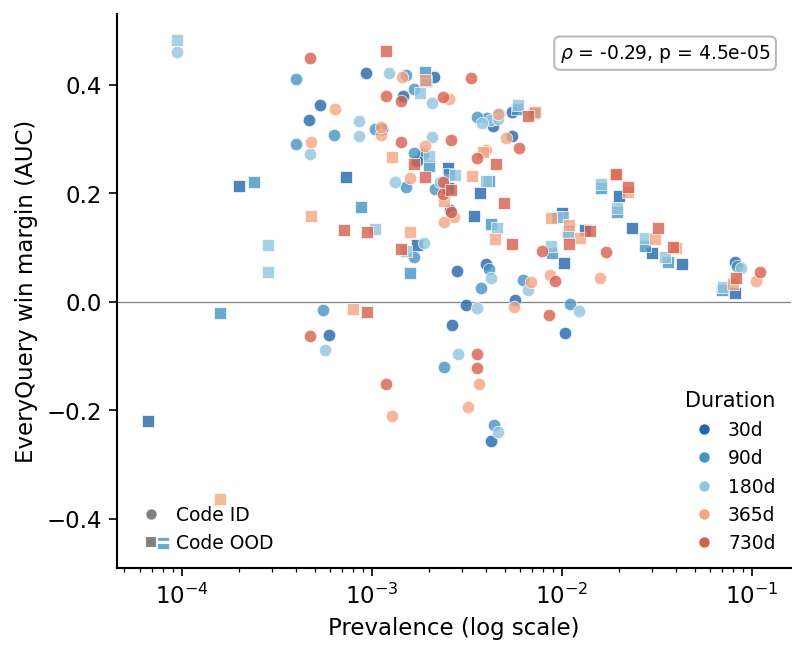

Pooled Spearman (prevalence vs metric, all durations):
  rho(prev, ΔAUC):    -0.285  (p=0.0000)
  rho(prev, EQ AUC):  +0.094  (p=0.1878)
  rho(prev, EIC AUC): +0.544  (p=0.0000)


In [82]:
# Prevalence scatter
dur_palette = {30: "#2166AC", 90: "#4393C3", 180: "#92C5DE", 365: "#F4A582", 730: "#D6604D"}
bucket_markers = {"id": "o", "ood": "s"}
rho_delta, p_delta = sp_stats.spearmanr(df["prevalence"].to_numpy(), df["delta_auc"].to_numpy())

fig, ax = plt.subplots(figsize=(5.5, 4.5))

for dur in DURATIONS:
    for bkt, marker in bucket_markers.items():
        sub = df.filter((pl.col("duration_days") == dur) & (pl.col("bucket") == bkt))
        if len(sub) == 0:
            continue
        ax.scatter(sub["prevalence"].to_numpy(), sub["delta_auc"].to_numpy(),
                   c=dur_palette[dur], marker=marker, s=36, alpha=0.8,
                   edgecolors="white", linewidths=0.4, zorder=3)

ax.axhline(0, color="0.5", linewidth=0.6, linestyle="-", zorder=1)
ax.set_xscale("log")
ax.set_xlabel("Prevalence (log scale)")
ax.set_ylabel("EveryQuery win margin (AUC)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(0.97, 0.95, f"$\\rho$ = {rho_delta:+.2f}, p = {p_delta:.1e}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7", alpha=0.9))

leg_dur = [Line2D([0], [0], marker="o", color="w", markerfacecolor=dur_palette[d],
                   markersize=6, label=f"{d}d") for d in DURATIONS]
leg_bkt = [Line2D([0], [0], marker="o", color="w", markerfacecolor="0.5", markersize=6, label="Code ID"),
           Line2D([0], [0], marker="s", color="w", markerfacecolor="0.5", markersize=6, label="Code OOD")]

l1 = ax.legend(handles=leg_dur, frameon=False, fontsize=9, loc="lower right",
               title="Duration", title_fontsize=10, handletextpad=0.3, borderpad=0.3)
ax.add_artist(l1)
ax.legend(handles=leg_bkt, frameon=False, fontsize=9, loc="lower left",
          handletextpad=0.3, borderpad=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_prevalence_scatter.png", bbox_inches="tight", dpi=300)
plt.show()

# Pooled Spearman correlations (all durations combined)
prev_all = df["prevalence"].to_numpy()
delta_all = df["delta_auc"].to_numpy()
eq_all = df["occurs_auc"].to_numpy()
eic_all = df["eic_auc"].to_numpy()

rho_delta, p_delta = sp_stats.spearmanr(prev_all, delta_all)
rho_eq, p_eq = sp_stats.spearmanr(prev_all, eq_all)
rho_eic, p_eic = sp_stats.spearmanr(prev_all, eic_all)

print("Pooled Spearman (prevalence vs metric, all durations):")
print(f"  rho(prev, ΔAUC):    {rho_delta:+.3f}  (p={p_delta:.4f})")
print(f"  rho(prev, EQ AUC):  {rho_eq:+.3f}  (p={p_eq:.4f})")
print(f"  rho(prev, EIC AUC): {rho_eic:+.3f}  (p={p_eic:.4f})")

## Analysis 7: Embedding Analysis with Multi-Duration Queries

In [83]:
import seaborn as sns
import umap
from sklearn.metrics.pairwise import cosine_similarity

FIG_DIR = REPO / "analysis" / "figures"

EMBED_PARQUET = (
    EQ_MODEL_DIR / "eval" / "best"
    / "eval_embeds_10000_ID__8db2be6fadf8_20260413_201311.parquet"
)
HOSP_EMBED_PARQUET = (
    EQ_MODEL_DIR / "eval" / "best"
    / "eval_embeds_hosp_admin_codes_20260414_015447.parquet"
)

# Schema check (lazy scan, no embeddings loaded)
lf = pl.scan_parquet(EMBED_PARQUET)
row_count = lf.select(pl.len()).collect().item()
n_subjects = lf.select(pl.col("subject_id").n_unique()).collect().item()
n_codes = lf.select(pl.col("code").n_unique()).collect().item()
durations_found = sorted(
    lf.select("duration_days").unique().collect()["duration_days"].to_list()
)
print(f"Rows: {row_count:,}, Subjects: {n_subjects:,}, Codes: {n_codes}, Durations: {durations_found}")

# Seven query codes spanning different clinical categories
QUERY_CODES = {
    "Lab: PT": "LAB//51274//sec//value_[14.1,15.3)",
    "Lab: Osmolality": "LAB//50964//mOsm/kg//value_[288.0,293.0)",
    "Dx: Afib": "DIAGNOSIS//ICD//9//4271",
    "Dx: CKD": "DIAGNOSIS//ICD//9//5856",
    "Med: Gabapentin": "MEDICATION//Gabapentin//Delayed Administered",
    "Med: Captopril stop": "MEDICATION//STOP//Captopril",
    "Death": "MEDS_DEATH",
}
CODE_TO_LABEL = {v: k for k, v in QUERY_CODES.items()}
SELECTED_CODES = list(QUERY_CODES.values())
N_SAMPLE = 150

# Remap duration 731 -> 730 to match notebook convention
dur_remap = (
    pl.when(pl.col("duration_days") == 731)
    .then(pl.lit(730))
    .otherwise(pl.col("duration_days"))
    .alias("duration_days")
)

# Step 1: Find subjects present at all 5 durations for the selected codes
# (load only metadata columns, not embeddings)
meta = (
    pl.scan_parquet(EMBED_PARQUET)
    .filter(pl.col("code").is_in(SELECTED_CODES))
    .with_columns(dur_remap)
    .select("subject_id", "code", "duration_days")
    .collect()
)

# Subjects present at all 5 durations (for any single code -- they're the same across codes)
dur_coverage = (
    meta.filter(pl.col("code") == SELECTED_CODES[0])
    .group_by("subject_id")
    .agg(pl.col("duration_days").n_unique().alias("n_durs"))
    .filter(pl.col("n_durs") == 5)
)
eligible_subjects = dur_coverage["subject_id"]
print(f"Subjects with all 5 durations: {len(eligible_subjects):,}")

# Sample N_SAMPLE subjects
np.random.seed(42)
sampled_ids = np.random.choice(
    eligible_subjects.to_numpy(), size=min(N_SAMPLE, len(eligible_subjects)), replace=False
)
sample_df = pl.DataFrame({"subject_id": sampled_ids})

# Collect embeddings for sampled subjects x selected codes x all durations
embed_df = (
    pl.scan_parquet(EMBED_PARQUET)
    .filter(pl.col("code").is_in(SELECTED_CODES))
    .with_columns(dur_remap)
    .join(sample_df.lazy(), on="subject_id", how="semi")
    .select("subject_id", "code", "duration_days", "embedding")
    .collect()
)

# Add short label column
embed_df = embed_df.with_columns(
    pl.col("code").replace(CODE_TO_LABEL).alias("label")
)

# Extract numpy matrix
embed_mat = np.stack(embed_df["embedding"].to_list())

print(f"Embedding matrix shape: {embed_mat.shape}")
print(f"Unique codes: {embed_df['label'].n_unique()}")
print(f"Unique durations: {sorted(embed_df['duration_days'].unique().to_list())}")
print(f"Unique subjects: {embed_df['subject_id'].n_unique()}")

Rows: 1,993,051, Subjects: 15,031, Codes: 41, Durations: [30, 90, 180, 365, 731]
Subjects with all 5 durations: 4,213
Embedding matrix shape: (5250, 768)
Unique codes: 7
Unique durations: [30, 90, 180, 365, 730]
Unique subjects: 150


UMAP projection shape: (5250, 2)


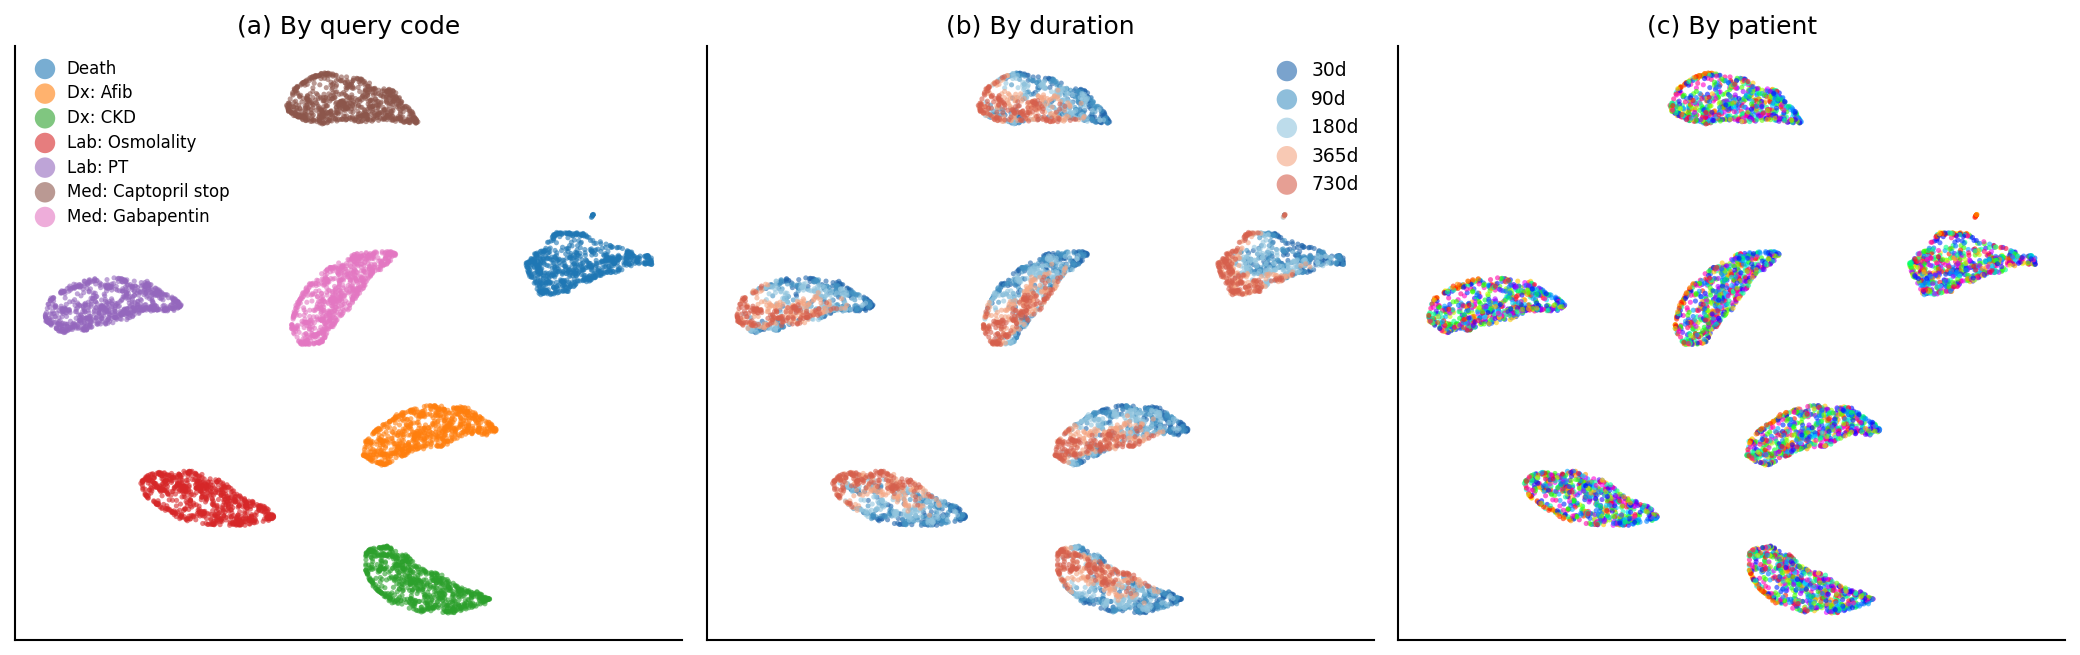

In [84]:
reducer = umap.UMAP(
    n_neighbors=30, min_dist=0.3, metric="cosine",
    random_state=42, n_jobs=1,
)
umap_2d = reducer.fit_transform(embed_mat)

embed_df = embed_df.with_columns(
    pl.Series("umap_x", umap_2d[:, 0]),
    pl.Series("umap_y", umap_2d[:, 1]),
)
print(f"UMAP projection shape: {umap_2d.shape}")

# UMAP projection (3 panels)
dur_palette = {30: "#2166AC", 90: "#4393C3", 180: "#92C5DE", 365: "#F4A582", 730: "#D6604D"}
code_labels = sorted(embed_df["label"].unique().to_list())
code_palette = {label: plt.cm.tab10(i) for i, label in enumerate(code_labels)}


def plot_embed_panels(coords_2d, fig_path_stem, title=None, axis_labels=None):
    """Reusable 1x3 embedding scatter: by code, duration, patient."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    kw = dict(s=6, alpha=0.6, edgecolors="none", rasterized=True)

    # (a) By query code
    ax = axes[0]
    for label in code_labels:
        mask = embed_df["label"].to_numpy() == label
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                   color=code_palette[label], label=label, **kw)
    ax.legend(fontsize=8, markerscale=4, loc="best", frameon=False,
              handletextpad=0.3, borderpad=0.3, labelspacing=0.4)
    ax.set_title("(a) By query code", fontsize=12)

    # (b) By duration
    ax = axes[1]
    d_arr = embed_df["duration_days"].to_numpy()
    for dur in DURATIONS:
        mask = d_arr == dur
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                   color=dur_palette[dur], label=f"{dur}d", **kw)
    ax.legend(fontsize=9, markerscale=4, loc="best", frameon=False,
              handletextpad=0.3, borderpad=0.3)
    ax.set_title("(b) By duration", fontsize=12)

    # (c) By patient
    ax = axes[2]
    s_arr = embed_df["subject_id"].to_numpy()
    prng = np.random.RandomState(0)
    u_subjs = np.unique(s_arr)
    cmap = dict(zip(u_subjs, [plt.cm.hsv(prng.random()) for _ in u_subjs]))
    ax.scatter(coords_2d[:, 0], coords_2d[:, 1],
               c=[cmap[s] for s in s_arr], **kw)
    ax.set_title("(c) By patient", fontsize=12)

    for ax in axes:
        if axis_labels:
            ax.set_xlabel(axis_labels[0], fontsize=10)
            ax.set_ylabel(axis_labels[1], fontsize=10)
            ax.tick_params(labelsize=9)
        else:
            ax.set_xticks([])
            ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    if title:
        fig.suptitle(title, fontsize=14, y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{fig_path_stem}.png", bbox_inches="tight", dpi=300)
    plt.show()


plot_embed_panels(umap_2d, "fig_embed_umap")

/var/folders/lf/0hr4t0g11t35265rmv8nv0vh0000gn/T/ipykernel_93334/3748491590.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="Group", y="Cosine similarity",


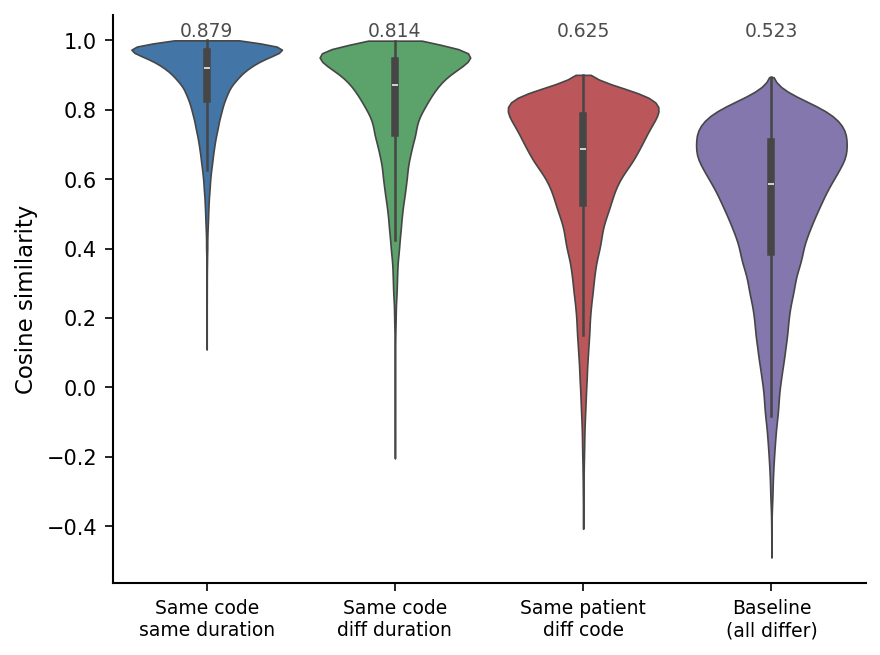

Group                           Mean  Median     Std
-------------------------------------------------------
Same code, same duration      0.8793  0.9204  0.1165
Same code, diff duration      0.8141  0.8696  0.1656
Same patient, diff code       0.6250  0.6856  0.2110
Baseline, (all differ)        0.5233  0.5854  0.2376

Mann-Whitney U (adjacent groups):
  Same code, same duration > Same code, diff duration: U=1568678881, p=0.00e+00
  Same code, diff duration > Same patient, diff code: U=1990379615, p=0.00e+00
  Same patient, diff code > Baseline, (all differ): U=1610258891, p=0.00e+00


In [85]:
MAX_PAIRS = 50_000
rng = np.random.RandomState(42)

labels_arr = embed_df["label"].to_numpy()
dur_arr = embed_df["duration_days"].to_numpy()
subj_arr = embed_df["subject_id"].to_numpy()

# Build indices
group_idx = {}  # (label, duration) -> [row indices]
subj_idx = {}   # subject_id -> [row indices]
for i in range(len(embed_df)):
    group_idx.setdefault((labels_arr[i], dur_arr[i]), []).append(i)
    subj_idx.setdefault(subj_arr[i], []).append(i)

def cap(arr, n=MAX_PAIRS):
    return rng.choice(arr, size=n, replace=False) if len(arr) > n else arr

# Group 1: Same code, same duration, different patients
sims = np.concatenate([
    cosine_similarity(embed_mat[idxs])[np.triu_indices(len(idxs), k=1)]
    for idxs in group_idx.values() if len(idxs) > 1
])
sim_groups = {"Same code\nsame duration": cap(sims)}

# Group 2: Same code, different duration, different patients
sims = []
for label in sorted(set(labels_arr)):
    durs = sorted(d for (l, d) in group_idx if l == label)
    for di, d1 in enumerate(durs):
        for d2 in durs[di + 1:]:
            i1, i2 = group_idx[(label, d1)], group_idx[(label, d2)]
            cs = cosine_similarity(embed_mat[i1], embed_mat[i2])
            mask = subj_arr[i1][:, None] != subj_arr[i2][None, :]
            sims.append(cs[mask])
sim_groups["Same code\ndiff duration"] = cap(np.concatenate(sims))

# Group 3: Same patient, different codes
sims = []
for subj, idxs in subj_idx.items():
    codes = np.unique(labels_arr[idxs])
    if len(codes) < 2:
        continue
    for ci, c1 in enumerate(codes):
        for c2 in codes[ci + 1:]:
            r1 = [j for j in idxs if labels_arr[j] == c1]
            r2 = [j for j in idxs if labels_arr[j] == c2]
            sims.append(cosine_similarity(embed_mat[r1], embed_mat[r2]).ravel())
sim_groups["Same patient\ndiff code"] = cap(np.concatenate(sims))

# Group 4: Baseline (all differ) -- rejection sampling then batch dot product
all_keys = list(group_idx.keys())
idx1, idx2 = [], []
while len(idx1) < MAX_PAIRS:
    ka = rng.randint(0, len(all_keys), size=MAX_PAIRS * 2)
    kb = rng.randint(0, len(all_keys), size=MAX_PAIRS * 2)
    for a, b in zip(ka, kb):
        k1, k2 = all_keys[a], all_keys[b]
        if k1[0] == k2[0] or k1[1] == k2[1]:
            continue
        i1, i2 = rng.choice(group_idx[k1]), rng.choice(group_idx[k2])
        if subj_arr[i1] == subj_arr[i2]:
            continue
        idx1.append(i1); idx2.append(i2)
        if len(idx1) >= MAX_PAIRS:
            break
m1, m2 = embed_mat[idx1], embed_mat[idx2]
sim_groups["Baseline\n(all differ)"] = np.sum(
    (m1 / np.linalg.norm(m1, axis=1, keepdims=True))
    * (m2 / np.linalg.norm(m2, axis=1, keepdims=True)), axis=1
)

# --- Violin plot ---
group_order = list(sim_groups.keys())
palette = ["#3A76AF", "#55A868", "#C44E52", "#8172B2"]

plot_data = [{"Group": g, "Cosine similarity": float(v)}
             for g in group_order for v in sim_groups[g]]
plot_df = pl.DataFrame(plot_data).to_pandas()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.violinplot(data=plot_df, x="Group", y="Cosine similarity",
               order=group_order, palette=palette, inner="box",
               linewidth=0.8, ax=ax, cut=0, saturation=0.85)

ax.set_xlabel("")
ax.set_ylabel("Cosine similarity")
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotate means above each violin
for i, g in enumerate(group_order):
    m = sim_groups[g].mean()
    ax.text(i, ax.get_ylim()[1] - 0.02, f"{m:.3f}",
            ha="center", va="top", fontsize=9, color="0.3")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_embed_cosine_sim.png", bbox_inches="tight", dpi=300)
plt.show()

# Summary + Mann-Whitney U
print(f"{'Group':<28} {'Mean':>7} {'Median':>7} {'Std':>7}")
print("-" * 55)
for g in group_order:
    v = sim_groups[g]
    print(f"{g.replace(chr(10), ', '):<28} {v.mean():>7.4f} {np.median(v):>7.4f} {v.std():>7.4f}")

print("\nMann-Whitney U (adjacent groups):")
for i in range(len(group_order) - 1):
    g1, g2 = group_order[i], group_order[i + 1]
    stat, p = sp_stats.mannwhitneyu(sim_groups[g1], sim_groups[g2], alternative="greater")
    print(f"  {g1.replace(chr(10), ', ')} > {g2.replace(chr(10), ', ')}: U={stat:.0f}, p={p:.2e}")

## Duration Monotonicity Check

Validates that the model has learned coherent temporal semantics: for a fixed
(patient, code), P(event in longer window) should be >= P(event in shorter window).

In [86]:
# Duration monotonicity check
# Part A: Raw P(event) per patient
PREDS_PARQUET = (
    EQ_MODEL_DIR / "eval" / "best"
    / "eval_preds_10000_ID__8db2be6fadf8_20260413_201311.parquet"
)

preds_raw = pl.read_parquet(PREDS_PARQUET).with_columns(
    pl.when(pl.col("duration_days") == 731).then(730)
    .otherwise(pl.col("duration_days")).alias("duration_days")
)

# Filter to subjects with all 5 durations per code
dur_counts = (
    preds_raw.group_by("subject_id", "code")
    .agg(pl.col("duration_days").n_unique().alias("n_dur"))
    .filter(pl.col("n_dur") == len(DURATIONS))
)
preds_full = preds_raw.join(dur_counts.select("subject_id", "code"), on=["subject_id", "code"], how="semi")

print(f"Subjects x codes with all {len(DURATIONS)} durations: {len(dur_counts):,}")
print(f"Predictions after filtering: {len(preds_full):,}")

# Pivot to wide: one row per (subject, code), columns = duration probs
wide = (
    preds_full
    .pivot(on="duration_days", index=["subject_id", "code"], values="occurs_probs")
    .sort("subject_id", "code")
)
# Check consecutive-pair violations
consecutive_pairs = list(zip(sorted(DURATIONS)[:-1], sorted(DURATIONS)[1:]))
violation_rows = []
for code in sorted(wide["code"].unique().to_list()):
    sub = wide.filter(pl.col("code") == code)
    n_subj = len(sub)
    # A subject violates if any consecutive pair has P(shorter) > P(longer)
    any_violation = None
    pair_violations = {}
    for d_short, d_long in consecutive_pairs:
        col_short, col_long = str(d_short), str(d_long)
        pair_viol = (sub[col_short] > sub[col_long]).sum()
        pair_violations[f"{d_short}->{d_long}"] = int(pair_viol)
        mask = sub[col_short] > sub[col_long]
        any_violation = mask if any_violation is None else (any_violation | mask)
    n_any = int(any_violation.sum())
    # Truncate code name for display
    code_short = code if len(code) <= 45 else code[:42] + "..."
    violation_rows.append({
        "code": code_short,
        "n_subjects": n_subj,
        "n_violations": n_any,
        "violation_rate": round(n_any / n_subj, 4),
        **{k: v for k, v in pair_violations.items()},
    })

viol_df = pl.DataFrame(violation_rows).sort("violation_rate", descending=True)
print("\nPer-patient monotonicity violations (any consecutive pair)")
print(f"Overall violation rate: "
      f"{viol_df['n_violations'].sum()} / {viol_df['n_subjects'].sum()} "
      f"({viol_df['n_violations'].sum() / viol_df['n_subjects'].sum():.1%})")
print()
print(viol_df)


Subjects x codes with all 5 durations: 172,733
Predictions after filtering: 863,665

Per-patient monotonicity violations (any consecutive pair)
Overall violation rate: 17839 / 172733 (10.3%)

shape: (41, 8)
┌──────────────┬────────────┬──────────────┬──────────────┬────────┬─────────┬──────────┬──────────┐
│ code         ┆ n_subjects ┆ n_violations ┆ violation_ra ┆ 30->90 ┆ 90->180 ┆ 180->365 ┆ 365->730 │
│ ---          ┆ ---        ┆ ---          ┆ te           ┆ ---    ┆ ---     ┆ ---      ┆ ---      │
│ str          ┆ i64        ┆ i64          ┆ ---          ┆ i64    ┆ i64     ┆ i64      ┆ i64      │
│              ┆            ┆              ┆ f64          ┆        ┆         ┆          ┆          │
╞══════════════╪════════════╪══════════════╪══════════════╪════════╪═════════╪══════════╪══════════╡
│ LAB//225672/ ┆ 4213       ┆ 792          ┆ 0.188        ┆ 156    ┆ 53      ┆ 56       ┆ 717      │
│ /IU/L//value ┆            ┆              ┆              ┆        ┆         ┆        

/var/folders/lf/0hr4t0g11t35265rmv8nv0vh0000gn/T/ipykernel_93334/2648093051.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


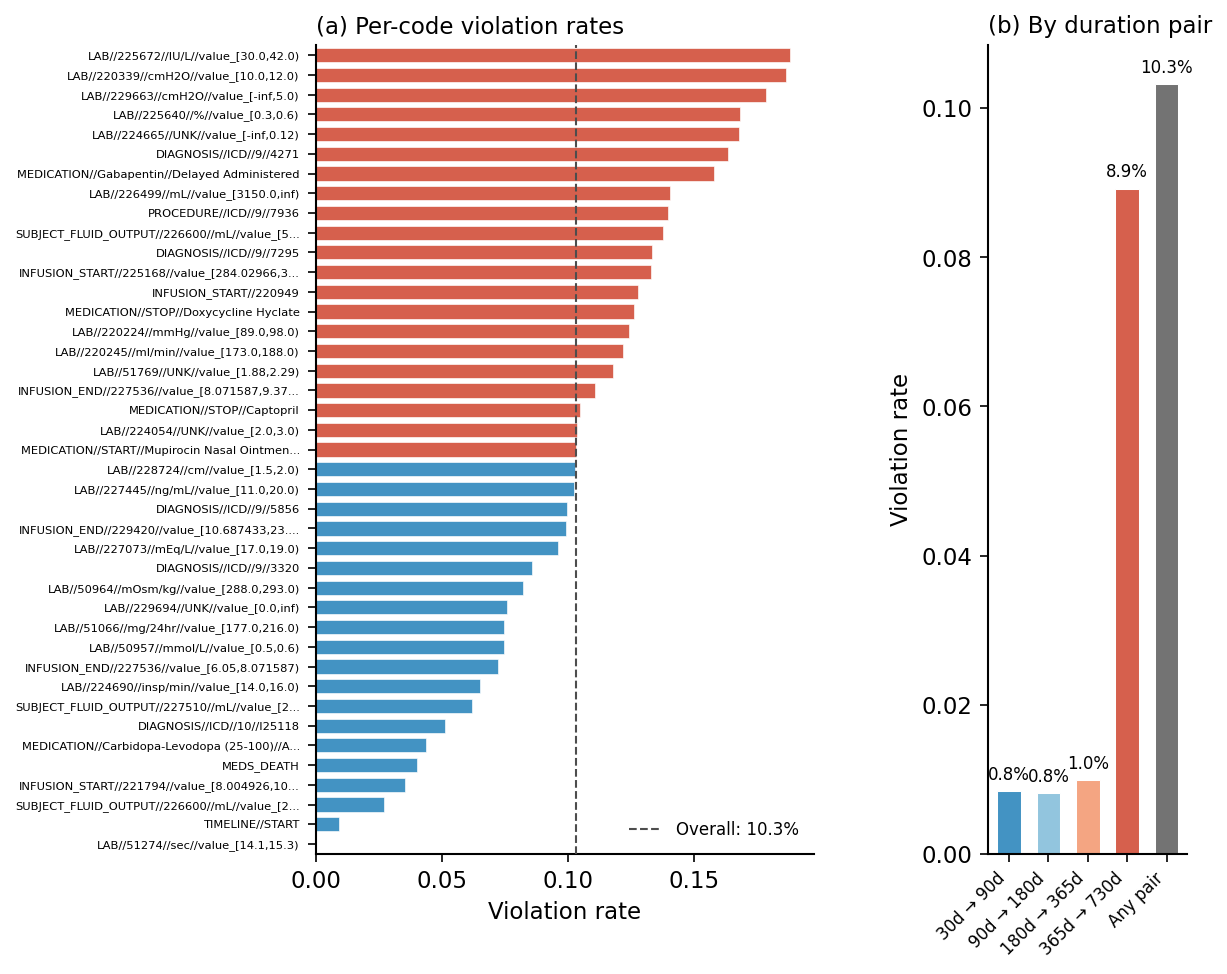

In [87]:
pair_cols_fig = [f"{d_short}->{d_long}" for d_short, d_long in consecutive_pairs]
pair_labels_fig = [f"{d_short}d \u2192 {d_long}d" for d_short, d_long in consecutive_pairs]
overall_rate = viol_df["n_violations"].sum() / viol_df["n_subjects"].sum()

fig, (ax_a, ax_b) = plt.subplots(
    1, 2, figsize=(7.5, 7),
    gridspec_kw={"width_ratios": [3, 1.2], "wspace": 0.5},
)

# (a) Per-code violation rates, sorted ascending
sorted_viol = viol_df.sort("violation_rate")
codes_display = sorted_viol["code"].to_list()
rates = sorted_viol["violation_rate"].to_numpy()

bar_colors = np.where(rates > overall_rate, "#D6604D", "#4393C3")
y_pos = np.arange(len(codes_display))
ax_a.barh(y_pos, rates, color=bar_colors, height=0.72,
          edgecolor="white", linewidth=0.3)
ax_a.axvline(overall_rate, color="0.3", ls="--", lw=1, zorder=5,
             label=f"Overall: {overall_rate:.1%}")
ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(codes_display, fontsize=5.5)
ax_a.set_xlabel("Violation rate")
ax_a.set_title("(a) Per-code violation rates", fontsize=11, loc="left")
ax_a.legend(fontsize=8, frameon=False, loc="lower right")
ax_a.set_ylim(-0.5, len(codes_display) - 0.5)

# (b) Per-pair aggregate violation rates + overall
pair_agg = [viol_df[pc].sum() / viol_df["n_subjects"].sum()
            for pc in pair_cols_fig]
pair_agg.append(overall_rate)
x_labels = pair_labels_fig + ["Any pair"]
x_colors = ["#4393C3", "#92C5DE", "#F4A582", "#D6604D", "0.45"]

bars = ax_b.bar(range(len(x_labels)), pair_agg, color=x_colors,
                edgecolor="white", linewidth=0.5, width=0.6)
ax_b.set_xticks(range(len(x_labels)))
ax_b.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
ax_b.set_ylabel("Violation rate")
ax_b.set_title("(b) By duration pair", fontsize=11, loc="left")

for bar, val in zip(bars, pair_agg):
    ax_b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
              f"{val:.1%}", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "fig_monotonicity.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_monotonicity.png", bbox_inches="tight", dpi=300)
plt.show()